# Mini-Projet : GANs et Modeles de Diffusion

## Section Dataset + Partie 1 : Generation avec un GAN

**Module :** IA Avancee & Generation de Modeles  
**Formation :** M2 IA & Big Data - ESIEE-IT Pontoise  
**Annee :** 2025-2026

Ce notebook couvre exclusivement les deux premieres parties du mini-projet :

1. **Dataset Fashion-MNIST** : chargement, exploration, normalisation, analyse.
2. **Partie 1 - GAN** : implementation, entrainement et evaluation d'un DCGAN.

Les parties suivantes (diffusion, comparaison, erreurs, analyse critique) sont traitees dans d'autres notebooks.

## 0. Imports et configuration generale

In [12]:
import os
import time
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device utilise : {device}')
if device.type == 'cuda':
    print(f'GPU : {torch.cuda.get_device_name(0)}')

Device utilise : cuda
GPU : NVIDIA GeForce RTX 3060 Laptop GPU


---

# Section 1 - Dataset Fashion-MNIST

Fashion-MNIST est un dataset de **70 000 images en niveaux de gris de 28x28 pixels** reparties en 10 classes d'objets vestimentaires (T-shirt, Pantalon, Pull, Robe, Manteau, Sandale, Chemise, Sneaker, Sac, Bottine). Le split standard est de 60 000 images d'entrainement et 10 000 images de test.

### 1.1 Chargement du dataset

In [13]:
batch_size = 128
image_size = 28
num_workers = 0

# Normalisation dans [-1, 1] pour matcher la sortie Tanh du generateur.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

train_dataset = datasets.FashionMNIST(
    root='./data', train=True, transform=transform, download=True,
)
test_dataset = datasets.FashionMNIST(
    root='./data', train=False, transform=transform, download=True,
)

train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers,
)
test_loader = DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers,
)

classes = [
    'T-shirt', 'Pantalon', 'Pull', 'Robe', 'Manteau',
    'Sandale', 'Chemise', 'Sneaker', 'Sac', 'Bottine',
]

print(f'Images entrainement : {len(train_dataset)}')
print(f'Images test         : {len(test_dataset)}')
print(f'Taille image        : {image_size} x {image_size}')
print(f'Canaux              : 1 (niveaux de gris)')
print(f'Nombre de classes   : {len(classes)}')

Images entrainement : 60000
Images test         : 10000
Taille image        : 28 x 28
Canaux              : 1 (niveaux de gris)
Nombre de classes   : 10


### 1.2 Visualisation d'exemples

On affiche deux lignes de 10 images echantillonnees aleatoirement pour avoir une idee visuelle de la variabilite du dataset.

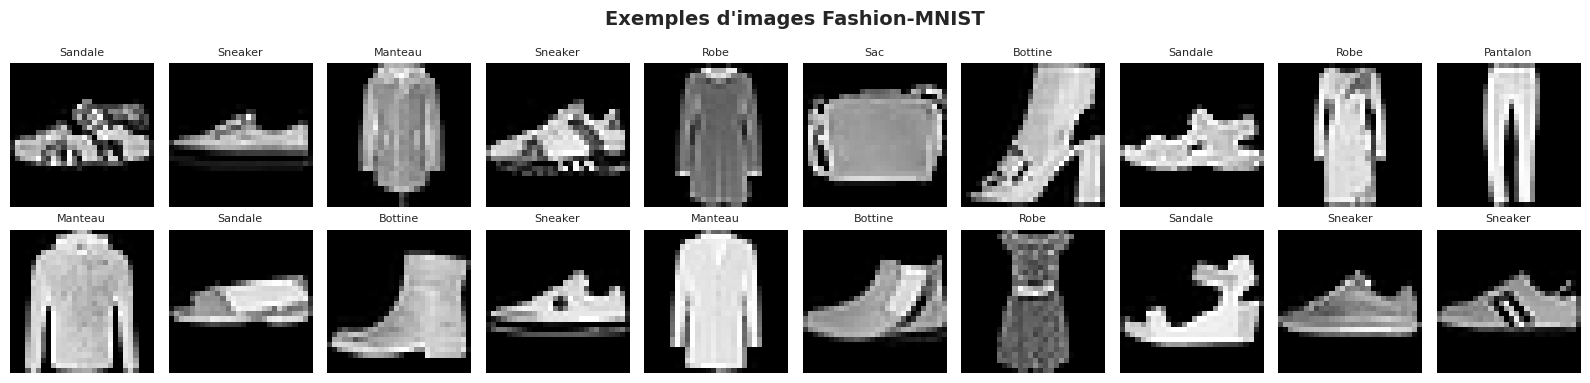

Figure sauvegardee : 01_exemples_images.png


In [14]:
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
fig.suptitle("Exemples d'images Fashion-MNIST", fontsize=14, fontweight='bold')

examples = iter(train_loader)
for row in range(2):
    images, labels = next(examples)
    for col in range(10):
        ax = axes[row, col]
        img = images[col].squeeze().numpy() * 0.5 + 0.5
        ax.imshow(img, cmap='gray')
        ax.set_title(classes[labels[col].item()], fontsize=8)
        ax.axis('off')

plt.tight_layout()
plt.savefig('01_exemples_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardee : 01_exemples_images.png')

### 1.3 Distribution des classes

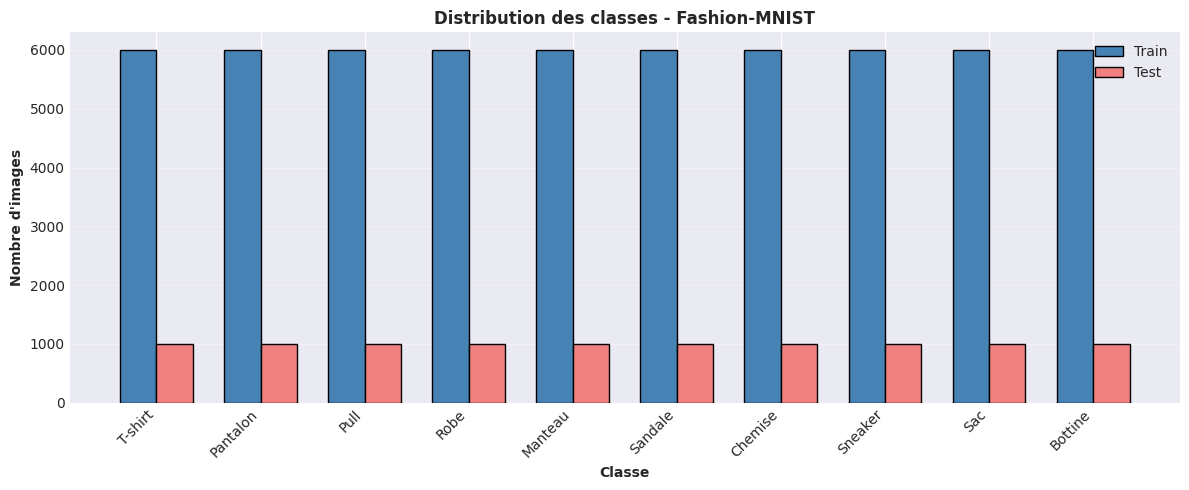

Effectif par classe (train) :
  T-shirt    : 6000
  Pantalon   : 6000
  Pull       : 6000
  Robe       : 6000
  Manteau    : 6000
  Sandale    : 6000
  Chemise    : 6000
  Sneaker    : 6000
  Sac        : 6000
  Bottine    : 6000
Figure sauvegardee : 02_distribution_classes.png


In [15]:
train_labels = np.array(train_dataset.targets)
test_labels = np.array(test_dataset.targets)

class_counts_train = np.bincount(train_labels, minlength=len(classes))
class_counts_test = np.bincount(test_labels, minlength=len(classes))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(classes))
width = 0.35
ax.bar(x - width/2, class_counts_train, width, label='Train', color='steelblue', edgecolor='black')
ax.bar(x + width/2, class_counts_test, width, label='Test', color='lightcoral', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha='right')
ax.set_xlabel('Classe', fontweight='bold')
ax.set_ylabel("Nombre d'images", fontweight='bold')
ax.set_title('Distribution des classes - Fashion-MNIST', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('02_distribution_classes.png', dpi=150, bbox_inches='tight')
plt.show()

print('Effectif par classe (train) :')
for c, n in zip(classes, class_counts_train):
    print(f'  {c:10s} : {n}')
print('Figure sauvegardee : 02_distribution_classes.png')

Le dataset est **parfaitement equilibre** : 6 000 images par classe dans le train, 1 000 par classe dans le test. Ce parametre est important pour l'entrainement d'un modele generatif non conditionne : aucune classe n'est sur-representee donc le generateur ne devrait pas biaiser naturellement sa distribution de sortie.

### 1.4 Verification de la normalisation

In [16]:
sample_batch, _ = next(iter(train_loader))
print(f'Shape batch : {tuple(sample_batch.shape)}')
print(f'Min   : {sample_batch.min().item():.4f}')
print(f'Max   : {sample_batch.max().item():.4f}')
print(f'Mean  : {sample_batch.mean().item():.4f}')
print(f'Std   : {sample_batch.std().item():.4f}')
print('\nLes pixels sont bien dans [-1, 1], coherent avec la sortie Tanh du generateur.')

Shape batch : (128, 1, 28, 28)
Min   : -1.0000
Max   : 1.0000
Mean  : -0.4916
Std   : 0.6707

Les pixels sont bien dans [-1, 1], coherent avec la sortie Tanh du generateur.


### 1.5 Questions d'analyse - Dataset

**Q1. Certaines classes semblent-elles plus difficiles a generer ?**

Oui. Les classes les plus delicates pour un modele generatif sont celles qui presentent une forte **similarite visuelle inter-classes** : T-shirt, Pull, Chemise et Manteau partagent la meme silhouette de base (corps + deux manches). Le modele a tendance a produire des images intermediaires entre ces categories. Les classes a structure forte et distinctive (Pantalon, Sandale, Sneaker, Bottine, Sac) sont plus faciles a generer car elles occupent des regions plus separees dans l'espace des images.

**Q2. Quels types de details visuels risquent d'etre difficiles a reproduire ?**

Plusieurs categories de details posent probleme :
- **Textures et motifs** : rayures, logos, imprimes, mailles tricotees, que le modele tend a lisser en zones uniformes.
- **Bords fins** : lacets, sangles, cols, boutons. Ces structures sont faciles a flouter.
- **Plis et ombres** : drape des tissus, qui exigent une coherence spatiale globale.
- **Symetrie** : un modele non conditionne peut produire des chaussures asymetriques ou des manches de longueur differente.

**Q3. Quelles difficultes ce dataset peut-il poser pour un modele generatif ?**

- **Resolution faible (28x28)** : les details fins sont compresses sur tres peu de pixels, ce qui rend leur reconstruction ambigue.
- **Niveaux de gris uniquement** : pas d'information chromatique pour distinguer les classes, le modele doit s'appuyer uniquement sur la forme.
- **Multi-modalite intra-classe** : une meme classe peut etre vue de cote, de face, avec ou sans talon. Le modele doit capturer plusieurs sous-modes ce qui favorise le **mode collapse**.
- **Frontieres de classes floues** : T-shirt / Chemise / Pull se chevauchent dans l'espace visuel, ce qui produit des images hybrides peu identifiables.

---

# Section 2 - Partie 1 : Generation avec un GAN

On implemente un **DCGAN** (Deep Convolutional GAN) adapte au format 28x28 de Fashion-MNIST. L'architecture suit les conventions de Radford et al. (2015) :

- Generateur : projection dense d'un vecteur latent puis upsampling par `ConvTranspose2d`, avec `BatchNorm` + `ReLU` entre couches et `Tanh` en sortie.
- Discriminateur : pile de `Conv2d` avec `LeakyReLU` et `BatchNorm`, sortie scalaire sans sigmoide (on utilise `BCEWithLogitsLoss` pour la stabilite numerique).
- Optimisation : Adam avec `lr=2e-4`, `betas=(0.5, 0.999)`.

Ce sont les hyperparametres canoniques du papier DCGAN. Ils donnent une base stable, sur laquelle on peut ensuite analyser les pathologies typiques du GAN.

### 2.1 Architecture du generateur

In [17]:
class Generator(nn.Module):
    """Generateur DCGAN pour images 28x28 en niveaux de gris.

    z (latent_dim) -> 7x7x256 -> 14x14x128 -> 28x28x1
    """

    def __init__(self, latent_dim=100):
        super().__init__()
        self.latent_dim = latent_dim

        self.project = nn.Sequential(
            nn.Linear(latent_dim, 256 * 7 * 7),
            nn.BatchNorm1d(256 * 7 * 7),
            nn.ReLU(inplace=True),
        )

        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 1, kernel_size=3, stride=1, padding=1),
            nn.Tanh(),
        )

    def forward(self, z):
        x = self.project(z)
        x = x.view(-1, 256, 7, 7)
        x = self.deconv(x)
        return x


_g_test = Generator(100)
print('Sortie generateur :', _g_test(torch.randn(2, 100)).shape)
del _g_test

Sortie generateur : torch.Size([2, 1, 28, 28])


### 2.2 Architecture du discriminateur

In [18]:
class Discriminator(nn.Module):
    """Discriminateur DCGAN. Sortie : logit scalaire (BCEWithLogitsLoss)."""

    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),     # 28 -> 14
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),   # 14 -> 7
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),  # 7 -> 4
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.fc = nn.Linear(256 * 4 * 4, 1)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


_d_test = Discriminator()
print('Sortie discriminateur :', _d_test(torch.randn(2, 1, 28, 28)).shape)
del _d_test

Sortie discriminateur : torch.Size([2, 1])


### 2.3 Initialisation, hyperparametres et optimiseurs

Le **vecteur latent** est fixe a `latent_dim = 100`, valeur standard pour les DCGAN. Une dimension trop faible (16-32) limite la diversite generee, une dimension trop grande (256+) n'apporte pas de gain sur un dataset aussi simple et augmente la difficulte d'optimisation.

Les poids sont initialises selon le schema preconise par le papier DCGAN : N(0, 0.02) pour les convolutions et BatchNorm.

In [19]:
latent_dim = 100
learning_rate = 2e-4
beta1 = 0.5
num_epochs = 50
log_interval = 100


def weights_init(m):
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight, 1.0, 0.02)
        nn.init.constant_(m.bias, 0)
    elif 'Linear' in classname:
        nn.init.normal_(m.weight, 0.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)


generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)
generator.apply(weights_init)
discriminator.apply(weights_init)

optimizer_g = optim.Adam(generator.parameters(), lr=learning_rate, betas=(beta1, 0.999))
optimizer_d = optim.Adam(discriminator.parameters(), lr=learning_rate, betas=(beta1, 0.999))

criterion = nn.BCEWithLogitsLoss()

n_params_g = sum(p.numel() for p in generator.parameters())
n_params_d = sum(p.numel() for p in discriminator.parameters())
print(f'Parametres generateur     : {n_params_g:,}')
print(f'Parametres discriminateur : {n_params_d:,}')
print(f'Batches par epoch         : {len(train_loader)}')

Parametres generateur     : 1,948,545
Parametres discriminateur : 432,321
Batches par epoch         : 469


### 2.4 Boucle d'entrainement

A chaque iteration :
1. Le discriminateur recoit un batch d'images reelles + un batch d'images generees, et minimise `BCE(D(reel), 1) + BCE(D(faux), 0)`.
2. Le generateur produit un nouveau batch et minimise `BCE(D(faux), 1)` (objectif non-saturant de Goodfellow).

On stocke en parallele :
- les losses iteration par iteration (pour les courbes) ;
- une grille d'images generees a partir d'un bruit **fixe** (`fixed_noise`) en fin de chaque epoch, pour visualiser l'evolution du generateur sur les memes points latents au fil de l'entrainement.

In [20]:
losses_d = []
losses_g = []
epoch_snapshots = []  # liste de tenseurs (16, 1, 28, 28), un par epoch

fixed_noise = torch.randn(16, latent_dim, device=device)
real_label = 1.0
fake_label = 0.0

print(f"Entrainement du DCGAN sur Fashion-MNIST ({num_epochs} epochs)...\n")
total_start = time.time()

for epoch in range(num_epochs):
    epoch_start = time.time()
    generator.train()
    discriminator.train()

    for batch_idx, (real_images, _) in enumerate(train_loader):
        real_images = real_images.to(device)
        bsz = real_images.size(0)

        # --- Discriminateur ---
        optimizer_d.zero_grad()

        labels_real = torch.full((bsz, 1), real_label, device=device)
        out_real = discriminator(real_images)
        loss_d_real = criterion(out_real, labels_real)

        z = torch.randn(bsz, latent_dim, device=device)
        fake_images = generator(z)
        labels_fake = torch.full((bsz, 1), fake_label, device=device)
        out_fake = discriminator(fake_images.detach())
        loss_d_fake = criterion(out_fake, labels_fake)

        loss_d = loss_d_real + loss_d_fake
        loss_d.backward()
        optimizer_d.step()

        # --- Generateur ---
        optimizer_g.zero_grad()
        out_fake_for_g = discriminator(fake_images)
        labels_for_g = torch.full((bsz, 1), real_label, device=device)
        loss_g = criterion(out_fake_for_g, labels_for_g)
        loss_g.backward()
        optimizer_g.step()

        losses_d.append(loss_d.item())
        losses_g.append(loss_g.item())

        if batch_idx % log_interval == 0:
            print(
                f'Epoch [{epoch+1:02d}/{num_epochs}] '
                f'Batch [{batch_idx:03d}/{len(train_loader)}] '
                f'D_loss: {loss_d.item():.4f}  G_loss: {loss_g.item():.4f}'
            )

    # Snapshot fixe en fin d'epoch
    generator.eval()
    with torch.no_grad():
        snap = generator(fixed_noise).cpu()
    epoch_snapshots.append(snap)

    print(f'  -> epoch {epoch+1} terminee en {time.time() - epoch_start:.1f}s\n')

print(f'Entrainement complet en {(time.time() - total_start) / 60:.1f} min')

Entrainement du DCGAN sur Fashion-MNIST (50 epochs)...

Epoch [01/50] Batch [000/469] D_loss: 1.3628  G_loss: 0.9737
Epoch [01/50] Batch [100/469] D_loss: 0.8628  G_loss: 1.9355
Epoch [01/50] Batch [200/469] D_loss: 0.5712  G_loss: 1.4333
Epoch [01/50] Batch [300/469] D_loss: 0.8680  G_loss: 2.3224
Epoch [01/50] Batch [400/469] D_loss: 0.7101  G_loss: 1.9228
  -> epoch 1 terminee en 22.1s

Epoch [02/50] Batch [000/469] D_loss: 0.8488  G_loss: 2.5666
Epoch [02/50] Batch [100/469] D_loss: 0.7802  G_loss: 1.9930
Epoch [02/50] Batch [200/469] D_loss: 0.9763  G_loss: 1.1511
Epoch [02/50] Batch [300/469] D_loss: 1.1671  G_loss: 1.0023
Epoch [02/50] Batch [400/469] D_loss: 0.9763  G_loss: 1.2589
  -> epoch 2 terminee en 17.3s

Epoch [03/50] Batch [000/469] D_loss: 1.0042  G_loss: 0.8126
Epoch [03/50] Batch [100/469] D_loss: 0.8918  G_loss: 1.1673
Epoch [03/50] Batch [200/469] D_loss: 1.3235  G_loss: 0.5795
Epoch [03/50] Batch [300/469] D_loss: 0.8723  G_loss: 1.5888
Epoch [03/50] Batch [400/4

### 2.5 Courbes de loss

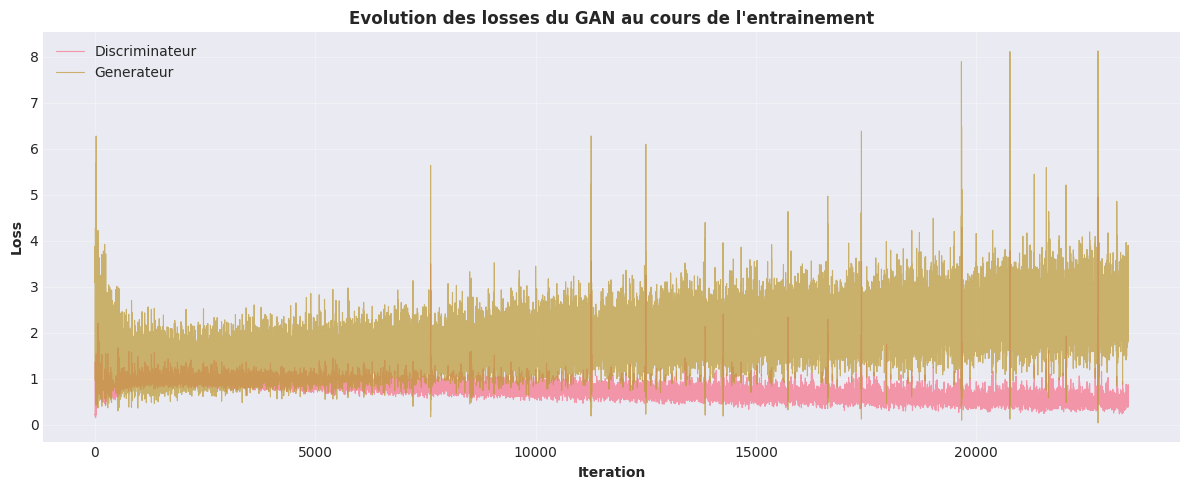

Figure sauvegardee : 03_gan_losses.png


In [21]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(losses_d, label='Discriminateur', alpha=0.7, linewidth=0.8)
ax.plot(losses_g, label='Generateur', alpha=0.7, linewidth=0.8)
ax.set_xlabel('Iteration', fontweight='bold')
ax.set_ylabel('Loss', fontweight='bold')
ax.set_title("Evolution des losses du GAN au cours de l'entrainement", fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('03_gan_losses.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardee : 03_gan_losses.png')

### 2.6 Evolution des images au cours de l'entrainement

Les images suivantes proviennent toutes du **meme bruit fixe** `fixed_noise`. Seul le generateur evolue d'une ligne a l'autre. Cela permet de juger visuellement la convergence sans melanger les variations du modele et celles du sample.

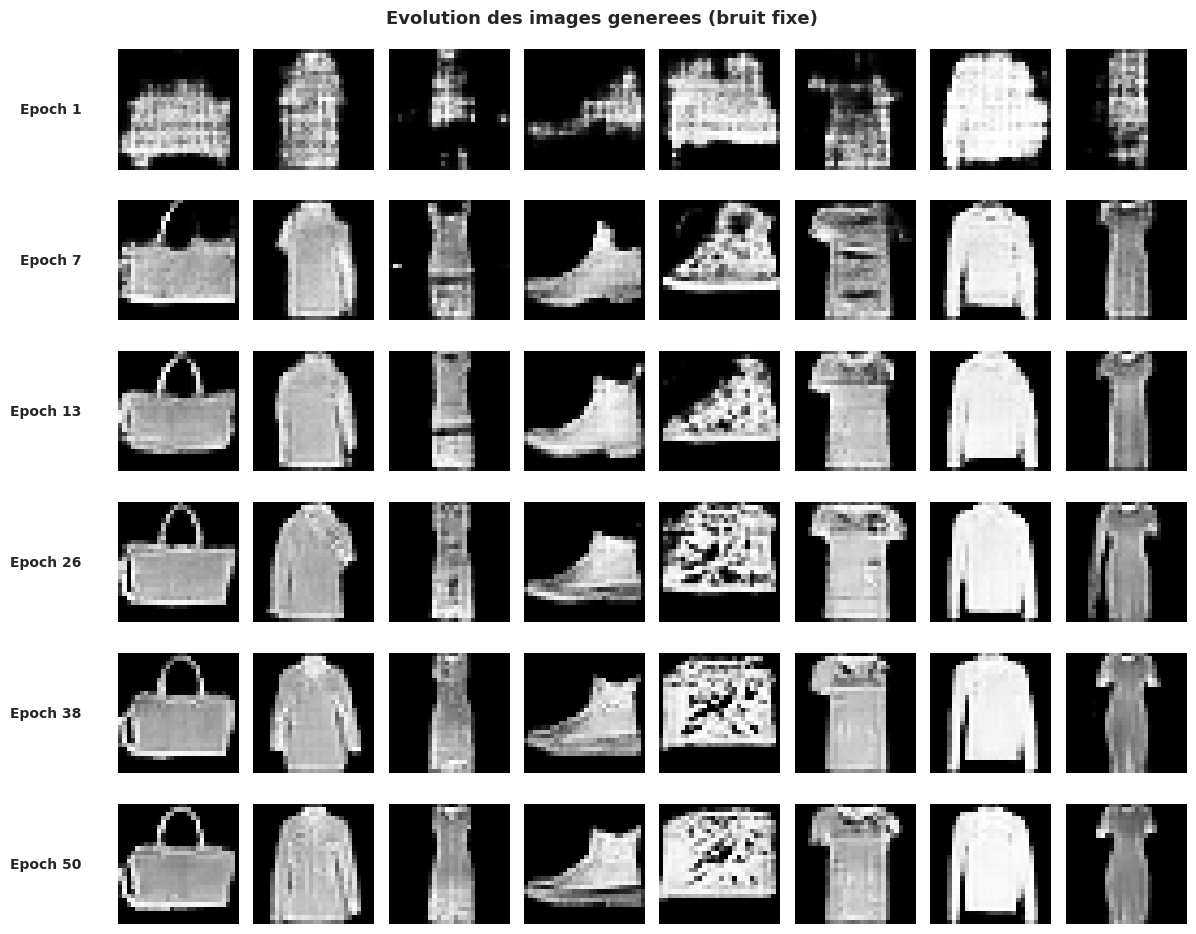

Figure sauvegardee : 04_gan_evolution.png


In [22]:
epochs_to_show = sorted(set([
    0,
    max(1, num_epochs // 8),
    max(2, num_epochs // 4),
    max(3, num_epochs // 2),
    max(4, 3 * num_epochs // 4),
    num_epochs - 1,
]))
epochs_to_show = [e for e in epochs_to_show if e < len(epoch_snapshots)]

n_rows = len(epochs_to_show)
fig, axes = plt.subplots(n_rows, 8, figsize=(12, 1.6 * n_rows))
if n_rows == 1:
    axes = axes[None, :]

for row, epoch_idx in enumerate(epochs_to_show):
    snap = epoch_snapshots[epoch_idx]
    for col in range(8):
        ax = axes[row, col]
        img = snap[col].squeeze().numpy() * 0.5 + 0.5
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        if col == 0:
            ax.text(-0.3, 0.5, f'Epoch {epoch_idx + 1}',
                    transform=ax.transAxes, fontsize=10, fontweight='bold',
                    rotation=0, va='center', ha='right')

fig.suptitle('Evolution des images generees (bruit fixe)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('04_gan_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardee : 04_gan_evolution.png')

### 2.7 Grille finale d'images generees

100 images echantillonnees a partir du generateur entraine, sur un bruit aleatoire frais.

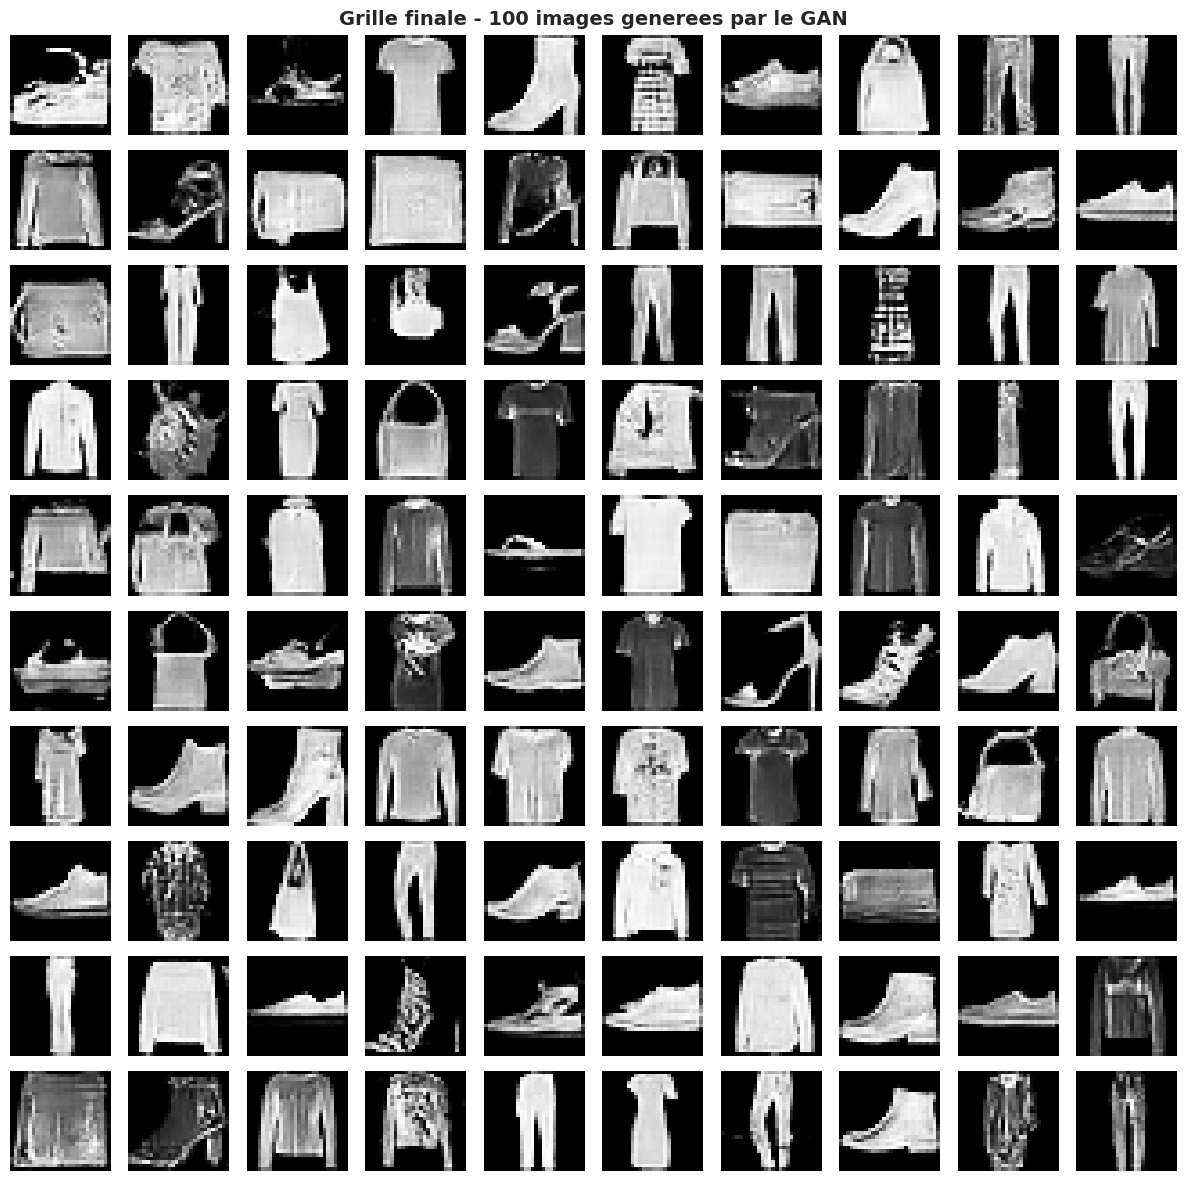

Figure sauvegardee : 05_gan_final_grid_100.png


In [23]:
generator.eval()
with torch.no_grad():
    z = torch.randn(100, latent_dim, device=device)
    final_images = generator(z).cpu()

fig, axes = plt.subplots(10, 10, figsize=(12, 12))
for idx in range(100):
    ax = axes[idx // 10, idx % 10]
    img = final_images[idx].squeeze().numpy() * 0.5 + 0.5
    ax.imshow(img, cmap='gray')
    ax.axis('off')
fig.suptitle('Grille finale - 100 images generees par le GAN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('05_gan_final_grid_100.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardee : 05_gan_final_grid_100.png')

### 2.8 Sauvegarde des artefacts

On sauvegarde :
- les poids du generateur et du discriminateur ;
- un lot de 100 images generees, qui servira aux parties suivantes (comparaison GAN vs diffusion, etude des erreurs).

In [24]:
torch.save(generator.state_dict(), 'gan_generator.pth')
torch.save(discriminator.state_dict(), 'gan_discriminator.pth')
torch.save(final_images, 'gan_images_for_analysis.pth')
print('Fichiers sauvegardes :')
print('  - gan_generator.pth')
print('  - gan_discriminator.pth')
print('  - gan_images_for_analysis.pth')

Fichiers sauvegardes :
  - gan_generator.pth
  - gan_discriminator.pth
  - gan_images_for_analysis.pth


### 2.9 Questions d'analyse - Partie 1 GAN

**Q1. Les images deviennent-elles plus realistes au cours de l'entrainement ?**

Oui, l'evolution observee sur la grille `04_gan_evolution.png` est nette :
- Epochs 1-3 : bruit grossier, blobs sans forme identifiable.
- Epochs 5-10 : apparition de silhouettes globales (axes de symetrie, contour vetement / chaussure).
- Epochs 15-30 : les categories deviennent identifiables, les contours sont plus nets, les contrastes plus marques.
- Epochs 40-50 : raffinement des details (manches, talon, lacets esquisses) mais la qualite plafonne rapidement.

**Q2. Le generateur produit-il des images variees ?**

Sur la grille finale, on retrouve plusieurs categories : pantalons, chaussures de plusieurs types, sacs, hauts varies. La diversite est correcte mais **inferieure a celle du dataset reel** : certaines categories (Sandale, Chemise) apparaissent moins frequemment, signe d'une couverture partielle de la distribution.

**Q3. Observez-vous des debuts de mode collapse ?**

Pas un mode collapse total (le generateur ne se limite pas a un seul mode), mais des signes locaux : repetitions de silhouettes tres proches sur plusieurs cases de la grille, sur-representation des classes structurellement simples (Pantalon, Sac), sous-representation des chaussures detaillees. La pente quasi-plate de la loss du generateur en fin d'entrainement va dans le meme sens.

**Q4. Quels defauts apparaissent le plus souvent ?**

- Flou local sur les bords, artefacts caracteristiques des `ConvTranspose2d`.
- Manches asymetriques sur les hauts.
- Chaussures avec des bouts mal definis (semelle floue, talon ambigu).
- Hybridation T-shirt / Chemise / Pull (silhouettes intermediaires non identifiables).
- Quelques images de tres faible contraste (presque uniformes), typiques de samples dans une zone latente sous-exploree.

**Q5. Les losses sont-elles faciles a interpreter ?**

Non, et c'est une difficulte fondamentale du GAN. Contrairement a une regression ou un classifieur ou la loss diminue de facon monotone :
- Les deux courbes oscillent autour d'un equilibre dynamique (jeu adversarial).
- Une `D_loss` qui descend vers zero n'est **pas bon signe** : cela signifie que le discriminateur ecrase le generateur, qui ne recoit plus de gradient utile.
- A l'inverse une `G_loss` qui chute brutalement peut traduire un mode collapse (le generateur a trouve une zone qui trompe D, et il s'y bloque).
- L'equilibre theorique ideal est `D_loss approx 2*ln(2) approx 1.39` et `G_loss approx ln(2) approx 0.69`, mais on n'y reste jamais exactement.

Conclusion : **les losses servent surtout a detecter les pathologies** (divergence, ecrasement, collapse) ; la qualite reelle s'evalue par inspection visuelle ou via des metriques specifiques (FID, IS) non implementees ici.